In [10]:
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import jax
import jax.numpy as jnp
from scipy.optimize import minimize
from scipy.sparse.linalg import LinearOperator, eigsh, eigs

jax.config.update("jax_enable_x64", True)
Array = jnp.ndarray

In [11]:
@dataclass
class PDESolver:
    n_cells: int = 32
    n_blocks: int = 8
    length: float = 1.0
    rhs_scale: float = 10.0
    dtype: jnp.dtype = jnp.float64

    def __post_init__(self):
        if self.n_cells % self.n_blocks != 0:
            raise ValueError("n_cells must be divisible by n_blocks")

        self.block_size = self.n_cells // self.n_blocks
        self.n_nodes_1d = self.n_cells + 1
        self.N = self.n_nodes_1d**2
        self.theta_dim = self.n_blocks**2
        self.h = self.length / self.n_cells

        self._A_loc = np.array(
            [
                [2.0 / 3.0, -1.0 / 6.0, -1.0 / 3.0, -1.0 / 6.0],
                [-1.0 / 6.0, 2.0 / 3.0, -1.0 / 6.0, -1.0 / 3.0],
                [-1.0 / 3.0, -1.0 / 6.0, 2.0 / 3.0, -1.0 / 6.0],
                [-1.0 / 6.0, -1.0 / 3.0, -1.0 / 6.0, 2.0 / 3.0],
            ],
            dtype=np.float64,
        )

        self._build_indices()
        self._build_rhs_and_measurements()
        self._compile()

    @staticmethod
    def _ij_to_dof(i: int, j: int, n_nodes_1d: int) -> int:
        return n_nodes_1d * j + i

    def _build_indices(self):
        boundary = []
        for i in range(self.n_nodes_1d):
            boundary.append(self._ij_to_dof(i, 0, self.n_nodes_1d))
            boundary.append(self._ij_to_dof(i, self.n_nodes_1d - 1, self.n_nodes_1d))
        for j in range(1, self.n_nodes_1d - 1):
            boundary.append(self._ij_to_dof(0, j, self.n_nodes_1d))
            boundary.append(self._ij_to_dof(self.n_nodes_1d - 1, j, self.n_nodes_1d))
        boundary = np.array(sorted(set(boundary)), dtype=np.int32)

        row_entries: List[int] = []
        col_entries: List[int] = []
        theta_entry_ids: List[int] = []
        local_coeffs: List[float] = []

        for i in range(self.n_cells):
            for j in range(self.n_cells):
                theta_idx = (i // self.block_size) + (j // self.block_size) * self.n_blocks
                dof = [
                    self._ij_to_dof(i, j, self.n_nodes_1d),
                    self._ij_to_dof(i, j + 1, self.n_nodes_1d),
                    self._ij_to_dof(i + 1, j + 1, self.n_nodes_1d),
                    self._ij_to_dof(i + 1, j, self.n_nodes_1d),
                ]
                for p in range(4):
                    for q in range(4):
                        row_entries.append(dof[p])
                        col_entries.append(dof[q])
                        theta_entry_ids.append(theta_idx)
                        local_coeffs.append(float(self._A_loc[p, q]))

        self.boundaries = jnp.asarray(boundary, dtype=jnp.int32)
        self.row_entries = jnp.asarray(np.array(row_entries, dtype=np.int32), dtype=jnp.int32)
        self.col_entries = jnp.asarray(np.array(col_entries, dtype=np.int32), dtype=jnp.int32)
        self.theta_entry_ids = jnp.asarray(np.array(theta_entry_ids, dtype=np.int32), dtype=jnp.int32)
        self.local_coeffs = jnp.asarray(np.array(local_coeffs, dtype=np.float64), dtype=self.dtype)

    def _build_rhs_and_measurements(self):
        b = np.ones((self.N,), dtype=np.float64) * self.rhs_scale * (self.h**2)
        b[np.asarray(self.boundaries)] = 0.0
        self.b = jnp.asarray(b, dtype=self.dtype)

        xs = np.arange(1.0 / 14.0, 13.0 / 14.0, 1.0 / 14.0)

        def heaviside(x):
            return 0.0 if x < 0 else 1.0

        def S(x, y):
            h = self.h
            return heaviside(x) * heaviside(y) * (1 - heaviside(x - h)) * (1 - heaviside(y - h))

        def phi(x, y):
            h = self.h
            return (
                (x + h) * (y + h) * S(x + h, y + h)
                + (h - x) * (h - y) * S(x, y)
                + (x + h) * (h - y) * S(x + h, y)
                + (h - x) * (y + h) * S(x, y + h)
            ) / (h**2)

        M = np.zeros((13, 13, self.N), dtype=np.float64)
        for k in range(self.N):
            i0 = k % self.n_nodes_1d
            j0 = k // self.n_nodes_1d
            for i in range(13):
                for j in range(13):
                    M[i, j, k] = phi(xs[i] - self.h * i0, xs[j] - self.h * j0)
        self.M = jnp.asarray(M.reshape((13**2, self.N)), dtype=self.dtype)

    def _compile(self):
        boundaries = self.boundaries
        row_entries = self.row_entries
        col_entries = self.col_entries
        theta_entry_ids = self.theta_entry_ids
        local_coeffs = self.local_coeffs
        b = self.b

        @jax.jit
        def _solve_u(theta: Array) -> Array:
            vals = theta[theta_entry_ids] * local_coeffs
            A = jnp.zeros((self.N, self.N), dtype=theta.dtype)
            A = A.at[(row_entries, col_entries)].add(vals)
            A = A.at[boundaries, :].set(0.0)
            A = A.at[:, boundaries].set(0.0)
            A = A.at[(boundaries, boundaries)].set(1.0)
            return jnp.linalg.solve(A, b)

        @jax.jit
        def _predict_z(theta: Array) -> Array:
            u = _solve_u(theta)
            return self.M @ u

        self._solve_u = _solve_u
        self._predict_z = _predict_z

    def solve_u(self, theta: Array) -> Array:
        return self._solve_u(jnp.asarray(theta, dtype=self.dtype))

    def predict_z(self, theta: Array) -> Array:
        return self._predict_z(jnp.asarray(theta, dtype=self.dtype))

    def predict_z_from_log_theta(self, log_theta: Array) -> Array:
        return self.predict_z(jnp.exp(jnp.asarray(log_theta, dtype=self.dtype)))

In [12]:
@dataclass
class PosteriorModel:
    solver: PDESolver
    z_hat: Optional[Array] = None
    sigma_like: float = 0.05
    sigma_prior: float = 2.0
    prior_mean: float = 0.0

    @staticmethod
    def _load_default_z_hat() -> np.ndarray:
        return np.array(
            [
                0.06076511762259369, 0.09601910120848481, 0.1238852517838584, 0.1495184117375201, 0.1841596127549784, 0.2174525028261122, 0.2250996160898698, 0.2197954769002993, 0.2074695698370926, 0.1889996477663016, 0.1632722532153726, 0.1276782480038186, 0.07711845915789312,
                0.09601910120848552, 0.2000589533367983, 0.3385592591951766, 0.3934300024647806, 0.4040223892461541, 0.4122329537843092, 0.4100480091545554, 0.3949151637189968, 0.3697873264791232, 0.33401826235924, 0.2850397806663382, 0.2184260032478671, 0.1271121156350957,
                0.1238852517838611, 0.3385592591951819, 0.7119285162766475, 0.8175712861756428, 0.6836254116578105, 0.5779452419831157, 0.5555615956136897, 0.5285181561736719, 0.491439702849224, 0.4409367494853282, 0.3730060082060772, 0.2821694983395214, 0.1610176733857739,
                0.1495184117375257, 0.3934300024647929, 0.8175712861756562, 0.9439154625527653, 0.8015904115095128, 0.6859683749254024, 0.6561235366960599, 0.6213197201867315, 0.5753611315000049, 0.5140091754526823, 0.4325325506354165, 0.3248315148915482, 0.1834600412730086,
                0.1841596127549917, 0.4040223892461832, 0.6836254116578439, 0.8015904115095396, 0.7870119561144977, 0.7373108331395808, 0.7116558878070463, 0.6745179049094283, 0.6235300574156917, 0.5559332704045935, 0.4670304994474178, 0.3499809143811, 0.19688263746294,
                0.2174525028261253, 0.4122329537843404, 0.5779452419831566, 0.6859683749254372, 0.7373108331396063, 0.7458811983178246, 0.7278968022406559, 0.690479353535775, 0.6369176452710288, 0.5677443693743215, 0.4784738764865867, 0.3602190632823262, 0.2031792054737325,
                0.2250996160898818, 0.4100480091545787, 0.5555615956137137, 0.6561235366960938, 0.7116558878070715, 0.727896802240657, 0.7121928678670187, 0.6712187391428729, 0.6139157775591492, 0.547825166529538, 0.4677122687599031, 0.3587654911000848, 0.2050734291675918,
                0.2197954769003094, 0.3949151637190157, 0.5285181561736911, 0.6213197201867471, 0.6745179049094407, 0.690479353535786, 0.6712187391428787, 0.6178408289359514, 0.5453605027237883, 0.489575966490909, 0.4341716881061278, 0.3534389974779456, 0.2083227496961347,
                0.207469569837099, 0.3697873264791366, 0.4914397028492412, 0.5753611315000203, 0.6235300574157017, 0.6369176452710497, 0.6139157775591579, 0.5453605027237935, 0.4336604929612851, 0.4109641743019312, 0.3881864790111245, 0.3642640090182592, 0.2179599909280145,
                0.1889996477663011, 0.3340182623592461, 0.4409367494853381, 0.5140091754526943, 0.555933270404597, 0.5677443693743304, 0.5478251665295453, 0.4895759664908982, 0.4109641743019171, 0.395727260284338, 0.3778949322004734, 0.3596268271857124, 0.2191250268948948,
                0.1632722532153683, 0.2850397806663325, 0.373006008206081, 0.4325325506354207, 0.4670304994474315, 0.4784738764866023, 0.4677122687599041, 0.4341716881061055, 0.388186479011099, 0.3778949322004602, 0.3633362567187364, 0.3464457261905399, 0.2096362321365655,
                0.1276782480038148, 0.2184260032478634, 0.2821694983395252, 0.3248315148915535, 0.3499809143811097, 0.3602190632823333, 0.3587654911000799, 0.3534389974779268, 0.3642640090182283, 0.35962682718569, 0.3464457261905295, 0.3260728953424643, 0.180670595355394,
                0.07711845915789244, 0.1271121156350963, 0.1610176733857757, 0.1834600412730144, 0.1968826374629443, 0.2031792054737354, 0.2050734291675885, 0.2083227496961245, 0.2179599909279998, 0.2191250268948822, 0.2096362321365551, 0.1806705953553887, 0.1067965550010013,
            ],
            dtype=float,
        )

    def __post_init__(self):
        if self.z_hat is None:
            self.z_hat = self._load_default_z_hat()
        self.z_hat = jnp.asarray(self.z_hat, dtype=self.solver.dtype)

    def log_likelihood(self, log_theta: Array) -> Array:
        z_pred = self.solver.predict_z_from_log_theta(log_theta)
        misfit = z_pred - self.z_hat
        return -jnp.dot(misfit, misfit) / (2.0 * self.sigma_like**2)

    def log_prior(self, log_theta: Array) -> Array:
        diff = log_theta - self.prior_mean
        return -jnp.dot(diff, diff) / (2.0 * self.sigma_prior**2)

    def log_posterior(self, log_theta: Array) -> Array:
        return self.log_likelihood(log_theta) + self.log_prior(log_theta)

    def neg_log_posterior(self, log_theta: Array) -> Array:
        return -self.log_posterior(log_theta)

    def map_estimate(self, x0: np.ndarray, method: str = "L-BFGS-B") -> Dict[str, object]:
        neg_logpost_jit = jax.jit(lambda x: self.neg_log_posterior(x))
        grad_fun = jax.jit(jax.grad(lambda x: self.neg_log_posterior(x)))

        def fun(x: np.ndarray) -> float:
            return float(jax.device_get(neg_logpost_jit(jnp.asarray(x, dtype=self.solver.dtype))))

        def jac(x: np.ndarray) -> np.ndarray:
            g = grad_fun(jnp.asarray(x, dtype=self.solver.dtype))
            return np.asarray(jax.device_get(g), dtype=np.float64)

        res = minimize(fun=fun, x0=np.asarray(x0, dtype=np.float64), jac=jac, method=method)
        x_map = jnp.asarray(res.x, dtype=self.solver.dtype)
        return {
            "log_theta_map": x_map,
            "theta_map": jnp.exp(x_map),
            "log_post_map": self.log_posterior(x_map),
            "success": bool(res.success),
            "message": str(res.message),
            "nit": int(getattr(res, "nit", -1)),
        }

In [16]:
@dataclass
class InstantonResult:
    log_theta: Array
    qoi: Array
    rate: float
    lam: Array
    mu: float
    success: bool
    message: str
    history: List[Dict[str, float]]


def _normalize(v: Array, eps: float = 1e-14) -> Array:
    return v / jnp.maximum(jnp.linalg.norm(v), eps)


def _project_perp_unit(e: Array, x: Array) -> Array:
    return x - e * jnp.vdot(e, x)


@dataclass
class Instanton:
    posterior: PosteriorModel
    qoi_fn: Callable[[Array], Array]
    qoi_dim: int = 1  # Dimension of QoI (1 for scalar, 2 for 2D, etc.)

    def __post_init__(self):
        self.rate_fn = jax.jit(lambda x: -self.posterior.log_posterior(x))
        self.grad_rate = jax.jit(jax.grad(self.rate_fn))
        
        # For multi-dimensional QoI
        if self.qoi_dim == 1:
            self.grad_qoi = jax.jit(jax.grad(self.qoi_fn))
        else:
            self.grad_qoi = jax.jit(jax.jacobian(self.qoi_fn))
        
        self.rate_and_grad = jax.jit(jax.value_and_grad(self.rate_fn))
        
        if self.qoi_dim == 1:
            self.qoi_and_grad = jax.jit(jax.value_and_grad(self.qoi_fn))
        else:
            def qoi_and_jac(x):
                return self.qoi_fn(x), self.grad_qoi(x)
            self.qoi_and_grad = jax.jit(qoi_and_jac)

    def optimize(
        self,
        lbda: Array,
        targetObservable: Array,
        mu: float = 0.0,
        initialM: Optional[np.ndarray] = None,
        maxiter: int = 200,
        method: str = "L-BFGS-B",
    ) -> Tuple[Array, float, Array, Array]:
        m0 = np.asarray(initialM, dtype=np.float64) if initialM is not None else np.zeros((self.posterior.solver.theta_dim,), dtype=np.float64)
        
        lbda = jnp.asarray(lbda, dtype=self.posterior.solver.dtype)
        targetObservable = jnp.asarray(targetObservable, dtype=self.posterior.solver.dtype)

        def objective(m_np: np.ndarray):
            m = jnp.asarray(m_np, dtype=self.posterior.solver.dtype)
            rate, grad_rate = self.rate_and_grad(m)
            q, grad_q = self.qoi_and_grad(m)
            
            # Constraint: c = q - targetObservable
            c = q - targetObservable
            
            # Objective: J - lambda^T * c + 0.5 * mu * ||c||^2
            val = rate - jnp.dot(lbda, c) + 0.5 * mu * jnp.dot(c, c)
            
            # Gradient
            if self.qoi_dim == 1:
                grad = grad_rate - lbda * grad_q + mu * c * grad_q
            else:
                grad = grad_rate - grad_q.T @ lbda + mu * grad_q.T @ c
            
            return float(jax.device_get(val)), np.asarray(jax.device_get(grad), dtype=np.float64)

        def fun(x: np.ndarray) -> float:
            v, _ = objective(x)
            return v

        def jac(x: np.ndarray) -> np.ndarray:
            _, g = objective(x)
            return g

        res = minimize(fun=fun, x0=m0, jac=jac, method=method, options={"maxiter": maxiter})
        m = jnp.asarray(res.x, dtype=self.posterior.solver.dtype)
        obsValue = jnp.asarray(self.qoi_fn(m), dtype=self.posterior.solver.dtype)
        action = float(jax.device_get(self.rate_fn(m)))
        return obsValue, action, lbda, m

    def searchInstantonViaAugmented(
        self,
        targetObservable: Array,
        muMin: float = np.log10(5.0),
        muMax: float = np.log10(100.0),
        nMu: int = 8,
        initLbda: Optional[Array] = None,
        initialM: Optional[np.ndarray] = None,
        maxiter_optimize: int = 200,
        tol_constraint: float = 1e-6,
    ) -> InstantonResult:
        muList = np.logspace(muMin, muMax, nMu)
        targetObservable = jnp.asarray(targetObservable, dtype=self.posterior.solver.dtype)
        
        if initLbda is None:
            lbda = jnp.zeros((self.qoi_dim,), dtype=self.posterior.solver.dtype)
        else:
            lbda = jnp.asarray(initLbda, dtype=self.posterior.solver.dtype)
        
        m = initialM
        history: List[Dict[str, float]] = []

        for mu in muList:
            obsValue, action, _, m_j = self.optimize(
                lbda,
                targetObservable=targetObservable,
                mu=float(mu),
                initialM=m,
                maxiter=maxiter_optimize,
            )
            c = targetObservable - obsValue
            lbda = mu * c + lbda
            m = np.asarray(jax.device_get(m_j), dtype=np.float64)
            
            qoi_val = jax.device_get(obsValue)
            c_val = jax.device_get(c)
            constraint_norm = float(jnp.linalg.norm(c))
            
            history.append({
                "mu": float(mu),
                "lambda_norm": float(jnp.linalg.norm(lbda)),
                "qoi_norm": float(jnp.linalg.norm(jnp.asarray(qoi_val))),
                "rate": float(action),
                "constraint_norm": float(constraint_norm)
            })

        m_final = jnp.asarray(m, dtype=self.posterior.solver.dtype)
        q_final = jnp.asarray(self.qoi_fn(m_final), dtype=self.posterior.solver.dtype)
        rate_final = float(jax.device_get(self.rate_fn(m_final)))
        c_final = q_final - targetObservable
        constraint_norm_final = float(jnp.linalg.norm(c_final))
        msg = "constraint met" if constraint_norm_final <= tol_constraint else "constraint tolerance not met"

        return InstantonResult(
            log_theta=m_final,
            qoi=q_final,
            rate=rate_final,
            lam=lbda,
            mu=float(muList[-1]),
            success=bool(constraint_norm_final <= max(tol_constraint, 1e-4)),
            message=msg,
            history=history,
        )

    def exceedance_probability_estimate(
        self,
        result: InstantonResult,
        eps: float = 1.0,
        z_hat: float = 1.0,
        det_tol: float = 1e-8,
        eig_floor: float = 1e-10,
        sigma_prior: Optional[float] = 2,
        n_eigs: Optional[int] = None,
        projectMPerp: bool = True,
    ) -> Dict[str, object]:
        m = jnp.asarray(result.log_theta, dtype=self.posterior.solver.dtype)
        dim = int(m.size)
        C0_sqrt = sigma_prior * jnp.eye(dim, dtype=m.dtype)

        dq_raw = self.grad_qoi(m)
        dq = dq_raw[None, :] if self.qoi_dim == 1 else dq_raw
        lmda_kkt = jnp.atleast_1d(jnp.asarray(result.lam, dtype=m.dtype))
        J_inst = self.rate_fn(m)

        # 1. Define the Preconditioned Gradient and Gramian (Eq 2.19)
        # B has one column per QoI constraint in the preconditioned metric
        B = (C0_sqrt @ dq.T)
        G = dq @ (C0_sqrt @ (C0_sqrt @ dq.T))
        G = 0.5 * (G + G.T)
        G = G + eig_floor * jnp.eye(G.shape[0], dtype=G.dtype)
        G_det = jnp.linalg.det(G)

        def project_tangent(v: Array) -> Array:
            coeff = jnp.linalg.solve(G, B.T @ v)
            return v - B @ coeff

        @jax.jit
        def hessvec_J(v: Array) -> Array:
            return jax.jvp(self.grad_rate, (m,), (v,))[1]

        @jax.jit
        def hessvec_q_weighted(v: Array) -> Array:
            if self.qoi_dim == 1:
                return lmda_kkt[0] * jax.jvp(self.grad_qoi, (m,), (v,))[1]
            hq = jax.jvp(self.grad_qoi, (m,), (v,))[1]
            return jnp.tensordot(lmda_kkt, hq, axes=1)

        # 2. Operator Evaluation (Eq 2.20 & 2.21)
        # This remains structurally identical. It naturally evaluates the 
        # non-trivial eigenvalues of (I_n - Pi_par @ A @ Pi_par)
        @jax.jit
        def L_matvec(v: Array) -> Array:
            vin = project_tangent(v) if projectMPerp else v
            y = C0_sqrt @ vin
            Hy = hessvec_J(y) - hessvec_q_weighted(y)
            inner = vin - (C0_sqrt @ Hy)
            ldt = project_tangent(inner) if projectMPerp else inner
            return ldt

        def matvec_np(x_np: np.ndarray) -> np.ndarray:
            y = L_matvec(jnp.asarray(x_np, dtype=m.dtype))
            return np.asarray(jax.device_get(y), dtype=np.float64)

        op = LinearOperator((dim, dim), matvec=matvec_np, dtype=np.float64)
        k = int((dim - 1) if n_eigs is None else min(max(1, n_eigs), dim - 1))
        evals = eigsh(op, k=k, which="LM", tol=det_tol, return_eigenvectors=False)
        evals = np.real(evals)
        
        # Calculate eigenvalues of the Hessian, dropping the abs() as discussed!
        hessian_evals = 1.0 - evals
        if np.any(hessian_evals < -1e-5):
            import warnings
            warnings.warn("Negative eigenvalue detected. The instanton point is a saddle.")
            
        logdet = float(np.sum(np.log(np.clip(hessian_evals, eig_floor, None))))

        # 3. Evaluate the Density Estimate directly from Eq 2.18
        # We maintain your prior volume normalization for dimensional correctness
        prior_vol = (2.0 * jnp.pi * eps * sigma_prior**2) ** (dim / 2.0)
        codim = int(dq.shape[0])
        
        density_estimate = (
            (1.0 / z_hat) * prior_vol *
            (2.0 * jnp.pi * eps) ** (-0.5 * codim) *
            (G_det) ** (-0.5) * # det(G)^{-1/2}
            jnp.exp(-0.5 * logdet) * # det(I - Pi A Pi)^{-1/2}
            jnp.exp(-J_inst / eps)
        )

        # 4. Recover Exceedance Probability from the density
        # Using the standard tail approximation: P(q >= z) \approx p(z) * (\epsilon / |\lambda|)
        if lmda_kkt.size == 1:
            exceedance_prob = density_estimate * (eps / jnp.abs(lmda_kkt[0]))
        else:
            exceedance_prob = jnp.nan

        qoi_val = jax.device_get(self.qoi_fn(m))
        lam_val = jax.device_get(lmda_kkt)
        return {
            "qoi": float(qoi_val) if np.ndim(qoi_val) == 0 else np.asarray(qoi_val, dtype=np.float64).tolist(),
            "rate": float(jax.device_get(J_inst)),
            "lambda": float(lam_val) if np.ndim(lam_val) == 0 else np.asarray(lam_val, dtype=np.float64).tolist(),
            "logdet": float(logdet),
            "exceedance_prob": float(jax.device_get(exceedance_prob)),
            "density_estimate": float(jax.device_get(density_estimate)),
            "det_k": int(k),
        }


def qoi_block(log_theta: Array, ix: int = 0, iy: int = 1, n_blocks: int = 8) -> Array:
    """1D QoI: extract single block value"""
    blocks = jnp.reshape(log_theta, (n_blocks, n_blocks)).T
    return blocks[ix, iy]


def qoi_block_2d(log_theta: Array, ix_list, iy_list, n_blocks: int = 8) -> Array:
    """2D QoI: extract multiple block values as a vector"""
    blocks = jnp.reshape(log_theta, (n_blocks, n_blocks)).T
    return jnp.array([blocks[ix, iy] for ix, iy in zip(ix_list, iy_list)])


Evaluating 2D Instanton Density Grid...
Progress: 4/36
Progress: 8/36
Progress: 12/36
Progress: 16/36
Progress: 20/36
Progress: 24/36
Progress: 28/36
Progress: 32/36
Progress: 36/36


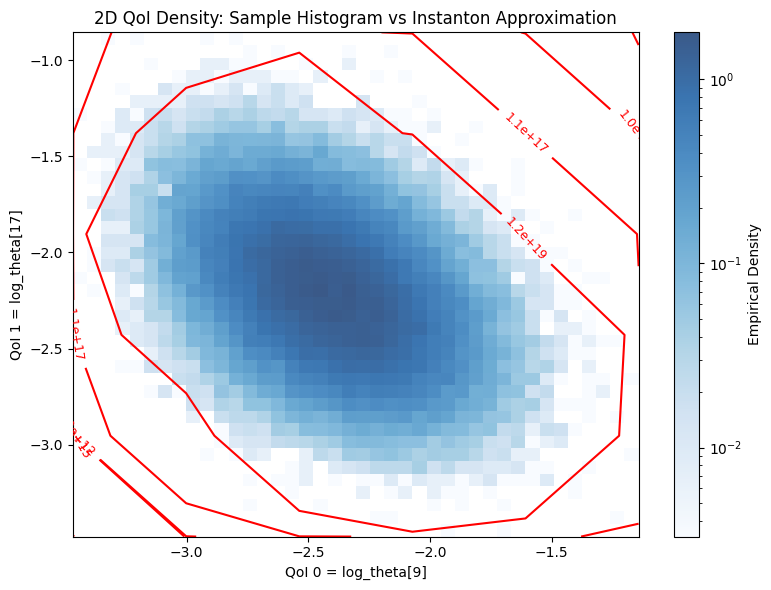

In [17]:
# 6) Overlay 2D instanton-based density estimates on empirical 2D histogram
from matplotlib.colors import LogNorm

print("\nEvaluating 2D Instanton Density Grid...")

# Speed/accuracy presets: set FAST_MODE=False for higher-quality results
FAST_MODE = True
if FAST_MODE:
    grid_res = 6
    n_mu_steps = 3
    n_eigs_density = 8
    maxiter_opt = 60
else:
    grid_res = 12
    n_mu_steps = 4
    n_eigs_density = 20
    maxiter_opt = 200

# Recreate instance so method updates in class definitions are picked up
instanton = Instanton(
    posterior=posterior,
    qoi_fn=instanton.qoi_fn,
    qoi_dim=2,
 )

# Extract the two 1D sample arrays
qoi1_samples = qoi_samples_2d[0]
qoi2_samples = qoi_samples_2d[1]

# Define bounds for the 2D grid based on sample data
z1_min, z1_max = float(np.min(qoi1_samples)), float(np.max(qoi1_samples))
z2_min, z2_max = float(np.min(qoi2_samples)), float(np.max(qoi2_samples))

# A 2D grid requires grid_res * grid_res solver evaluations.
z1_grid = np.linspace(z1_min, z1_max, grid_res)
z2_grid = np.linspace(z2_min, z2_max, grid_res)

# Create a 2D meshgrid (using 'ij' indexing so Z1[i, j] matches z1_grid[i], z2_grid[j])
Z1, Z2 = np.meshgrid(z1_grid, z2_grid, indexing='ij')
density_grid_2d = np.zeros_like(Z1)

# Initialize warm-start variables with the MAP estimate
m_init = np.asarray(jax.device_get(log_theta_map), dtype=np.float64)
lam_init = jnp.zeros(2, dtype=np.float64)

# Evaluate the Instanton solver over the 2D mesh
total = grid_res * grid_res
counter = 0
for i in range(grid_res):
    for j in range(grid_res):
        z_target_iter = jnp.array([Z1[i, j], Z2[i, j]], dtype=np.float64)

        res_z = instanton.searchInstantonViaAugmented(
            targetObservable=z_target_iter,
            muMin=np.log10(1.0),
            muMax=np.log10(1_000.0),
            nMu=n_mu_steps,
            initLbda=lam_init,
            initialM=m_init,
            maxiter_optimize=maxiter_opt,
        )

        # Calculate density estimate; lower n_eigs in FAST_MODE to reduce runtime
        est_z = instanton.exceedance_probability_estimate(
            res_z,
            eps=eps_for_Zhat,
            z_hat=float(Z_hat_laplace),
            n_eigs=n_eigs_density,
        )
        density_grid_2d[i, j] = est_z["density_estimate"]

        # Warm start the next grid point using the current solution to speed up convergence
        if res_z.success:
            m_init = np.asarray(jax.device_get(res_z.log_theta), dtype=np.float64)
            lam_init = jax.device_get(res_z.lam)

        counter += 1
        if counter % max(1, total // 8) == 0 or counter == total:
            print(f"Progress: {counter}/{total}")

# --- Plotting the 2D Overlay ---
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Plot the Empirical 2D Histogram (Log Scale)
h = ax.hist2d(
    qoi1_samples,
    qoi2_samples,
    bins=40,
    density=True,
    norm=LogNorm(),
    cmap='Blues',
    alpha=0.8
)
fig.colorbar(h[3], ax=ax, label='Empirical Density')

# 2. Plot the Theoretical Instanton Contours
# Filter out invalid values to prevent log warnings when creating contour levels
valid_densities = density_grid_2d[np.isfinite(density_grid_2d) & (density_grid_2d > 0)]
if valid_densities.size > 1:
    min_den = valid_densities.min()
    max_den = valid_densities.max()
    if max_den > min_den:
        levels = np.logspace(np.log10(min_den), np.log10(max_den), 8)
        cs = ax.contour(
            Z1,
            Z2,
            density_grid_2d,
            levels=levels,
            colors='red',
            linewidths=1.5,
            norm=LogNorm(),
        )
        ax.clabel(cs, inline=True, fmt='%.1e', fontsize=9, colors='red')

ax.set_xlabel(f"QoI 0 = log_theta[{qoi_idx_list[0]}]")
ax.set_ylabel(f"QoI 1 = log_theta[{qoi_idx_list[1]}]")
ax.set_title("2D QoI Density: Sample Histogram vs Instanton Approximation")

plt.tight_layout()
plt.show()